In [164]:
from dotenv import load_dotenv
load_dotenv()

True

In [165]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
from langgraph.types import interrupt,Command
from langgraph.checkpoint.memory import InMemorySaver
from typing import Literal

In [166]:
llm = ChatGroq(model="openai/gpt-oss-20b")

In [167]:
class MailState(BaseModel):
    query: str = ""
    draft: str = ""
    human_feedback: str = ""
    final_response: str = ""

In [168]:
###defining nodes
def DraftEmail(state: MailState) -> MailState:
    if state.human_feedback:
        draft=llm.invoke(f"""Rewrite the email for {state.query},
                         you have generated this draft mail: {state.draft},
                         Human Feedback to apply:{state.human_feedback}
                           """).content
    draft = llm.invoke(state.query).content
    state.draft = draft
    return state


def HumanFeedback(state: MailState) -> MailState:
    feedback = interrupt(
        {"draft_mail": state.draft, 
         "question": "do you want to continue or re-write the mail ?"} )
    fb =(feedback or "").strip().lower()
    if fb in ["continue", "yes","ok","proceed","approved"]:
        state.human_feedback = ""
        return state
    else:
        state.human_feedback = fb
        return state
    


def FinalizeNode(state: MailState) -> MailState:
    # Perform any final processing or validation here
    if state.human_feedback:
        state.final_response =  state.human_feedback
    else:
        print("Email sent successfully!")
        state.final_response = "Email sent successfully!"
    return state 


def conditional_routing(state: MailState) -> Literal["draft","final"]:
    if state.human_feedback:
        return "draft"
    else:
        return "final"   


In [169]:
graph_builder = StateGraph(MailState)

#add nodes to the graph
graph_builder.add_node("draft", DraftEmail)
graph_builder.add_node("humanfb", HumanFeedback)
graph_builder.add_node("final", FinalizeNode)

## edge connections
graph_builder.add_edge(START, "draft")
graph_builder.add_edge("draft", "humanfb")
graph_builder.add_conditional_edges("humanfb", conditional_routing)
graph_builder.add_edge("final", END)

graph= graph_builder.compile(checkpointer=InMemorySaver())

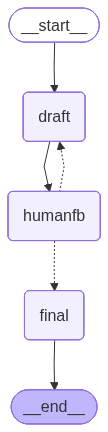

In [170]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [171]:
config = {"configurable":{"thread_id":"1"}}

In [172]:
res = graph.invoke({"query":"Please draft an email to my manager requesting a day off on july 15."}, config=config)
print(res["draft"])

**Subject:** Request for Personal Day Off – July 15, 2024  

Hi [Manager’s Name],

I hope you’re doing well. I’m writing to request a personal day off on **Tuesday, July 15, 2024**. I have already checked the team calendar and there are no major deadlines or meetings scheduled that day, so I anticipate minimal disruption.

To ensure continuity, I will:

- Finish all current tasks by the end of Monday, July 14.  
- Update the project tracker and leave detailed notes for any pending items.  
- Make myself available via email or phone if anything urgent arises.

Please let me know if you need any additional information or if there’s anything I should adjust in advance. Thank you for considering my request.

Best regards,

[Your Name]  
[Your Position]  
[Contact Information]


In [173]:
res = graph.invoke(Command(resume ="change date to july 28th"), config=config)  
print(res["draft"]) 


**Subject:** Request for Personal Day Off – July 15, 2024  

Hi [Manager’s Name],

I hope you’re doing well. I’m writing to formally request a personal day off on **Tuesday, July 15, 2024**.  

I’ve reviewed the team schedule and will ensure that all of my current tasks are either completed or delegated to a colleague (I’ve already spoken with [Colleague’s Name] who is willing to cover any urgent items). I will also be available by phone/email for any critical questions that may arise while I’m away.

Please let me know if you need any additional information or if there are any conflicts with this date. I appreciate your consideration and look forward to your approval.

Thank you!

Best regards,  
[Your Full Name]  
[Your Title]  
[Your Contact Information]
